# **1. Introducción a la Red Neuronal Artificial**

En este notebook se presentará cómo opera en un nivel básico el proceso de fordward en una Red Neuronal Artificial (ANN o NN) de una capa con seis neuronas. La idea es partir experimentando con el proceso más básico que realiza una NN cuando se le entrega un dato a la entrada y qué retorna a la salida. En los notebooks posteriores se mostrará cómo se entrena una NN para clasificar dígitos.

Autor: **Gabriel Olmos Leiva**

## **1.1 Importar PyTorch**

In [5]:
from torch import nn
import torch

## **1.2 Idea Básica de una Red Neuronal**

La red neuronal artificial busca imitar el funcionamiento de una neurona biológica, considerando que estas establecen múltiples conexiones con otras neuronas. En la siguiente figura se presenta un diagrama que ilustra cómo las neuronas artificiales se organizan en distintas capas, cada una con un número determinado de neuronas.

La capa de entrada representa los valores, técnicamente conocidos como **características**, que describen un ejemplo proveniente del mundo real. Cada ($x_1$, $x_2$, $\ldots$, $x_k$) corresponde a un valor numérico. Estos valores se propagan hacia la primera capa oculta, compuesta por ($h_j$) neuronas artificiales.

Las conexiones entre las características y las neuronas están representadas por flechas, las cuales corresponden a pesos (*weights*). Cada característica es ponderada por estos pesos y luego el resultado pasa a través de una función de activación.

Surge entonces la pregunta: ¿qué es una neurona artificial? Una neurona artificial se define como la combinación de una función lineal, que calcula una suma ponderada de las entradas, y una función no lineal, que introduce la capacidad de modelar relaciones complejas.


![ANN](../../assets/02_esquema_red_neuronal.png)

En este notebook se realizará el proceso de forward pass en una red neuronal que recibe tres datos de entrada y cuenta con una capa compuesta por seis neuronas. El objetivo es comprender qué ocurre a bajo nivel durante este proceso.

Antes de comenzar con la implementación en código, se presentará una descripción matemática de las operaciones involucradas. Si ya domina el producto punto entre vectores y la multiplicación de matrices, puede avanzar directamente a la sección de código sin inconvenientes.

Antes de implementar la Artificial Neural Network (ANN o NN) de tres entradas y seis neuronas, es importante comprender su formulación matemática. Supongamos que tenemos una muestra de entrada compuesta por tres características, la cual será procesada por una capa formada por seis neuronas. Matemáticamente, esta situación puede describirse de la siguiente manera:

$$x=
\begin{pmatrix}
x_1 \\
x_2 \\
% \vdots \\
x_3
\end{pmatrix}
$$

$$w=
\begin{pmatrix}
w_{11}\ w_{12} \ w_{13} \\
w_{21}\ w_{22} \ w_{23} \\
\vdots \\
w_{61}\ w_{62} \ w_{63} \\
\end{pmatrix}
$$

Lo que vamos hacer es el producto punto entre $x$ y $w$, considerando que para que la multiplicación matricial esté bien definida, el vector de entrada debe interpretarse como un vector columna de dimensión $3 \times 1$, mientras que la matriz de pesos $w$ tiene dimensión $6 \times 3$.

Sin embargo, el producto $w \cdot x$ sí está definido, ya que el número de columnas de $w$ coincide con el número de filas de $x$. El resultado de esta multiplicación será un vector columna de dimensión $6 \times 1$, donde cada componente corresponde a la salida de una neurona.

Es decir, cada neurona realiza un producto punto entre sus pesos asociados y el vector de entrada. En forma matricial, esto se puede expresar como:

$$
y = w \cdot x =
\begin{pmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23} \\
\vdots & \vdots & \vdots \\
w_{61} & w_{62} & w_{63}
\end{pmatrix}
\begin{pmatrix}
x_1 \\
x_2 \\
x_3
\end{pmatrix}
=
\begin{pmatrix}
\sum_{j=1}^{3} w_{1j} x_j \\
\sum_{j=1}^{3} w_{2j} x_j \\
\vdots \\
\sum_{j=1}^{3} w_{6j} x_j
\end{pmatrix}
$$

**Nota**: Para que se pueda multiplicar, columnas de $w$ debe ser igual a las filas de $x$

De esta forma, cada componente del vector de salida representa la activación lineal de una neurona antes de aplicar una función de activación.

De manera generalizada tenemos lo siguiente:
$$
y_i = \sum_{j=1}^{3} w_{ij} x_j
$$

#### **Formalización de la Multiplicación Matriz-Vector**

Sean:

$$
\mathbf{x} \in \mathbb{R}^{m \times 1} \quad \text{(vector de entrada)}
$$

$$
\mathbf{W} \in \mathbb{R}^{j \times k} \quad \text{(matriz de pesos)}
$$

**Condición de compatibilidad:**

Para que el producto $\mathbf{y} = \mathbf{W}\mathbf{x}$ esté definido, las dimensiones internas deben coincidir:

$$
\underbrace{(j \times \color{red}{k})}_{\mathbf{W}} \cdot \underbrace{(\color{red}{m} \times 1)}_{\mathbf{x}} \quad \Rightarrow \quad \color{red}{k = m}
$$

**Resultado:**

$$
\mathbf{y} \in \mathbb{R}^{j \times 1}
$$


#### **Para nuestro caso:**

Para nuestra red con **3 entradas** y **6 neuronas**:

$$
\mathbf{x} \in \mathbb{R}^{3 \times 1}, \quad \mathbf{W} \in \mathbb{R}^{6 \times 3}, \quad \mathbf{y} \in \mathbb{R}^{6 \times 1}
$$

$$
(6 \times \color{red}{3}) \cdot (\color{red}{3} \times 1) \to (6 \times 1) \quad \checkmark
$$

Todo lo anterior es una formalidad matemática, visualmente es lo que se presenta a continuación:

![red neuronal](../../assets/02_nn_pytorch_01.png)

Ahora vamos a partir con la actividad de realizar el proceso de multiplicación de manera "manual" (puede usar python para calcular).

### **1.2.1 Calcular el resultado en $y_1$ y $y_3$**

En esta primera tarea se deben definir los datos de entrada y los pesos (weights) que utilizará la red. Para ello, se emplearán las siguientes líneas de código, las cuales permiten generar pesos de forma aleatoria y asegurar que puedan reproducirse en ejecuciones posteriores.

Nuestro tensor (vector de característica) de entrada será: 

$$
x = [1, 2, 3]
$$

Calcula de manera manual los resultados a la salida de $y_1$ y $y_3$ utilizando los pesos que se muestran en ``linear.weight``.

In [6]:
torch.manual_seed(5) # Establecemos una semilla para poder replicar la capa lineal de la red neuronal

linear = nn.Linear(in_features=3, out_features=6, bias=False) # Creamos una capa lineal de 3 entradas y 6 salidas.

In [8]:
linear.weight

Parameter containing:
tensor([[ 0.3813, -0.4317,  0.4705],
        [ 0.3694,  0.4851, -0.4427],
        [-0.3875,  0.2747, -0.5389],
        [ 0.5706,  0.1229,  0.0746],
        [-0.4937,  0.1840,  0.2483],
        [ 0.0916,  0.5553,  0.1734]], requires_grad=True)

In [6]:
# linear

In [7]:
## Mostrar los pesos
# linear.weight

In [10]:
x = torch.tensor([1,2,3], dtype=torch.float32)

**Recuerda!**: Hacer el cálculo manual para $y_1$ y $y_3$, y luego verificar en código.

In [11]:
y = linear(x)
# y #Mostrar el resultado y comparar con los que obtuviste manual

**¿Se obtuvieron los mismos resultados?**

## **1.3 Función de Activación**

Para que una red neuronal esté completa, debe incluir una función no lineal, ya que una red formada solo por operaciones lineales tendría capacidades muy limitadas. Las salidas obtenidas anteriormente se procesarán ahora mediante una función de activación. En clases se revisaron distintas funciones de activación; en este caso, utilizaremos la función ReLU.

![función de activación](../../assets/02_nn_pytorch_02.png)

Matemáticamente lo que hace esta función de activación es lo siguiente:

$$
h(y_i) = \text{ReLU}(y_i) = 
\begin{cases} 
0 & \text{si } y_i \leq 0 \\
y_i & \text{si } y_i > 0 
\end{cases}
$$

La expresión generalizada para obtener todas las funciones de activación para la primera capa es:

$$
z_i = h\left( \sum_{j=1}^{3} w_{ij} x_j \right)
$$

De manera manual calcula todos los valores de $z_i$ y luego ejecuta la celda de código que aparece a continuación:

In [14]:
h = nn.ReLU() # Aquí estamos instanciando la función ReLU, es decir, esto posteriormente operará como una función donde se le puede entregar datos de entrada y la función aplicará la fórmula anterior

In [10]:
# h

In [15]:
z = h(y) # Ahora le pasamos como dato de entrada el tensor y a la función de activación

In [ ]:
## Muestra el resultado
# z

**¿Coincide con los resultados manuales?**

## **1.4 Resumen**

Hasta el momento evidenciamos dos procesos que ocurren en una red neuronal, que es el proceso de fordward donde matemáticamente es una multiplicación matricial de valores de entradas con pesos y luego pasan por una función de activación (función no lineal). Todavía falta ver más piezas del puzzle para lograr entender todo lo que ocurre en un entrenamiento de una red neuronal. En resumen, simplemente hicimos fluir los datos a nuestra red neuronal y obtuvimos distintas salidas por cada neurona.

**¿Qué más falta?**

Falta mucho más!

1. **¿Para qué queremos entrenar?**
2. **¿Por qué utilizar Python?**

# **2. Arquitectura Red Neuronal Artificial**

Ahora vamos a construir una arquitectura que concatena distintas capas lineales con distintas neuronas utilizando la Programación Orientada a Objetos. Luego vamos hacer el proceso de inferencia o hacer fluir los datos hacia adelante para ver qué sucede.

En caso de no saber Programación Orientada a Objetos (POO) te recomiendo revisar el notebook que se llamada "00_introducción_python". Por otro lado, podrás encontrar más información en este repositorio: [Curso de Python](https://github.com/GbrlOl/programacion-2).

## **2.1 Crear Red Neuronal**

In [17]:
import torch
from torch import nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Capas lineales
        self.fc1 = nn.Linear(3, 5, bias=False) # Tenemos una matriz de 3x5, es decir, recibe 3 entradas que se multiplican con 15 pesos que producen una salida de 5 valores.
        self.fc2 = nn.Linear(5, 4, bias=False)
        self.fc3 = nn.Linear(4, 2, bias=False)
        
        # Función de activación h(.)
        self.h = nn.ReLU()
    
    def forward(self, x):
        x = self.h(self.fc1(x))  # Primera capa + activación
        x = self.h(self.fc2(x))  # Segunda capa + activación
        x = self.h(self.fc3(x))  # Tercera capa + activación
        return x

**Nota:** La notación de ``fc`` viene de fully conected.

## **2.2 Instanciar la Red**

Instanciar la red hace referencia a declarar o crear. La clase "SimpleNet" se la asignamos al **objeto** model que tendrá los atributos y métodos de la clase. ¿Por qué tenemos un torch.manual_seed(5)?, únicamente para replicar los pesos aleatorios que se generan. 

Si quieres verificar, puedes experimentar quitando esa línea de código y ve si cambian los pesos de la primera capa. **Nota importante**: si quieres obtener los primeros pesos del inicio, debes reiniciar el notebook.

In [2]:
torch.manual_seed(5)  # Para reproducibilidad

model = SimpleNet()

Sigamos con la actividad...

## **2.3 Crear Entrada**

Estas serán las tres características que entrarán por la red neuronal.

In [19]:
x = torch.tensor([1.0, 2.0, 3.0])

Antes de seguir, si sabes lo que estamos haciendo debes responder estas simples preguntas: 

* ¿Cantidad de datos de entrada?
* ¿Cuántos datos deberíamos tener a la salida de la capa final?

Una vez que se respondieron las consultas es hora de hacer una inferencia.

In [20]:
# Proceso de inferencia o predicción
output = model(x)
output

tensor([0.3132, 0.0546], grad_fn=<ReluBackward0>)

Algo interesante que podemos hacer con la programación es que podemos acceder a los distintos componentes de nuestra red.

1. **¿Podemos ver la red neuronal?**

In [22]:
# print(model)

2. **¿Cuántos pesos tiene la red neuronal?**

In [ ]:
#Esta celda de código permite mostrar la forma de cada fc.
for name, param in model.named_parameters():
    print(name, param.shape)

In [ ]:
total_params = sum(param.numel() for param in model.parameters())
print(total_params)

3. **¿Podemos acceder a los pesos de cierta capa?**

**Importante**: Si en la clase los atributos de instancia no los llamastes ``fc_n`` y utilizaste otro nombre, debes llamarlos de esa manera para acceder a sus pesos. 

In [21]:
# print(model.fc1.weight)

# **3. ¿Cómo podemos utilizar datos reales?**

Una red neuronal puede recibir distintos tipos de información, como audio, imágenes, datos de sensores o texto. Sin embargo, en la práctica, al trabajar con PyTorch, toda esta información debe representarse en forma de tensores, que son la estructura de datos fundamental utilizada por la librería.

Ahora vamos a trabajar con el dataset MNIST. Pytorch tiene un módulo llamado ``torchvision`` que contiene distintos dataset para utilizarse en distintas tareas. Al ejecutar la celda de código de abajo podemos descargar el dataset en nuestro dispositivo.

* ``train_dataset``: Es un objeto que contiene el par imagen y label.

**poner figura de la ppt del deep learning**

### **3.1 Cargar Dataset MNIST**

In [28]:
from torchvision import datasets

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

In [43]:
image, label = train_dataset[50000]

In [30]:
# len(train_dataset)

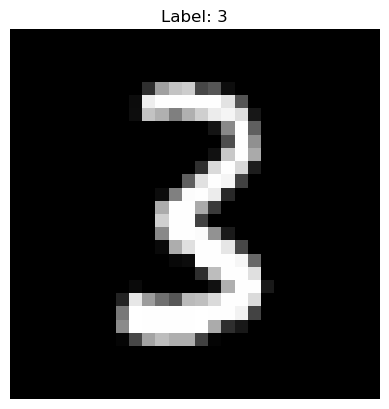

In [44]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

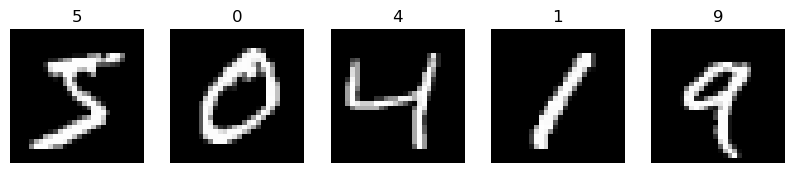

In [45]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    img, lbl = train_dataset[i]
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(lbl)
    axes[i].axis("off")

plt.show()

Tenemos en el objeto ``train_dataset`` 60.000 imágenes. ¿Podemos entregar las imágenes a la red neuronal directamente?

In [47]:
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform #Ahora introducimos un parámetro de entrada de la Clase MNIST que automáticamente convierte las imágenes a tensores
)
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [48]:
image, label = train_dataset[0] #Estamos tomando la primera muestra aquí

* Ahora aplica los atributos más importantes para entender la forma y tipo de datos

In [24]:
# Escribe tu código aquí

### **3.2 Crear Arquitectura**

Vamos a crear una ANN muy simple, capa de entrada, capa intermedia y la capa de salida. Pero antes de construir la red hay que preguntarse:

1. **¿Cómo entrará el tensor?, ¿Qué forma tendrá?**
2. **¿La capa intermedia estará proyectada hacia una neurona, dos neuronas o más neuronas en la capa de salida?**

#### **3.2.1 Aplanar la imagen**

In [54]:
# Convertimos la imagen de (1, 28, 28) -> (784)
x = image.view(-1)
x.shape 

torch.Size([784])

#### **3.2.2 Crear Red Neuronal**

In [56]:
class RedNeuronal(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(28*28, 64) # Aquí es importante entender que le entra 28x28 características que serían los píxeles
        self.activacion = nn.ReLU()
        self.capa_salida = nn.Linear(64, 10)  # 10 clases o etiquetas, que son los dígitos del 0 al 9. 

    # Construimos nuestro fordward donde secuencialmente juntamos las capas
    def forward(self, x):
        x = self.capa1(x)
        x = self.activacion(x)
        x = self.capa_salida(x)
        return x  # logits

#### **3.2.3 Instanciar Red Neuronal**

In [57]:
modelo = RedNeuronal()

In [42]:
# modelo

#### **3.2.4 Inferencia**

In [60]:
logits = modelo(x)
print("Logits:", logits)
print("Forma de salida:", logits.shape)  

Logits: tensor([ 0.1670,  0.1898, -0.0533,  0.0267,  0.0693,  0.0236,  0.0658, -0.0847,
        -0.0249, -0.0602], grad_fn=<ViewBackward0>)
Forma de salida: torch.Size([10])


Recordemos que los logits son los valores de salida de la red neuronal antes de aplicar una función de activación en la capa final. Estos valores pueden ser positivos, negativos y no representan una probabilidad.

#### **3.2.5 Convertir Logits a Probabilidades (Softmax)**

La **Softmax** transforma los logits en probabilidades, es decir, todos los valores quedan entre 0 y 1 (la suma debe dar 1). El parámetro **dim=0** indica en qué **dimensión** aplicamos la softmax. Debido a que tenemos un vector a la salida de los logits (dimensión 1) con 10 elementos, aplicamos softmax a la dimensión 0. Otra forma de entender esto es verlo como un eje, aplicamos softmax en el eje 0.

In [61]:
softmax = nn.Softmax(dim=0)
probabilidades = softmax(logits)

print("Probabilidades:", probabilidades)
print("Suma de probabilidades:", probabilidades.sum())

Probabilidades: tensor([0.1140, 0.1166, 0.0915, 0.0991, 0.1034, 0.0988, 0.1030, 0.0886, 0.0941,
        0.0908], grad_fn=<SoftmaxBackward0>)
Suma de probabilidades: tensor(1., grad_fn=<SumBackward0>)


#### **3.2.6 Predicción Final**

In [62]:
prediccion = torch.argmax(probabilidades)

print("Predicción del modelo:", prediccion.item())
print("Etiqueta real:", label)

Predicción del modelo: 1
Etiqueta real: 5


Las conclusiones son que el modelo hace una mala predicción. ¿A qué se debe esto?

# **4. Siguiente paso**

Ahora lo que falta es realizar un entrenamiento, para realizar este proceso debemos:

1. **Datos (Train, Validation y Test).**
2. **Definir Red Neuronal.**
3. **Crear DataLoader.**
4. **Crear Loop de Entrenamiento.**
5. **Monitorear entrenamiento.**
6. **Evaluar red neuronal.**
7. **Inferencia.**